In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Libreria de Tratamiento de Datos
from IPython.display import display

# Exploracion de Archivos
import sys
sys.path.append('../') # para que busque en carpeta src 
from src import sp_eda as se
from src import sp_carga_integracion as ci

# Funcion personalizada para asegurarnos que aparezcan todas las columnas
pd.set_option('display.max_columns', None) 

In [5]:
df = pd.read_csv(
    "../data/processed/02_datos_limpios.csv",
    parse_dates=['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro']
)

In [6]:
se.analisis_rapido(df)

Las 5 primeras columnas son:
                                                              0                                     1                                     2                                     3                                     4
order_id                                                     1                                     2                                     3                                     4                                     5
id_cliente                7ec28fa9-cad8-4f9a-a5b4-04a3f722c107  0f14d6ee-e853-448f-a20f-d6c933956321  5db0a392-f9b6-48c4-a1b0-bdd040ab4917  7cb936e9-265f-4e31-873d-7d17c93ac3d7  c11f579a-6506-4ac4-90ab-59a115a8ad7c
product_id                                               P0086                                 P0086                                 P0001                                 P0007                                 P0059
fecha_pedido                               2022-09-03 00:00:00                   2022-11-18 00:00:00          

In [7]:
clientes = df.groupby('id_cliente').agg(
    n_pedidos=('order_id', 'count'),
    gasto_total=('importe_total', 'sum'),
    edad=('edad', 'first'),
    ciudad=('ciudad', 'first'),
    segmento_cliente=('segmento_cliente', 'first'),
    ingresos_anuales=('ingresos_anuales', 'first'),
).reset_index()
clientes

,id_cliente,n_pedidos,gasto_total,edad,ciudad,segmento_cliente,ingresos_anuales
0,00047a8c-eaed-4e09-a302-4081b07e37f9,6,582.25,44.0,barcelona,corporativo,41626
1,0005530b-bb59-4862-9ed1-9ba4b57e4b95,8,714.03,64.0,granada,recurrente,64957
2,000c848f-a5fc-40a5-a3ba-3de5a7e12089,1,9.49,40.0,sevilla,nuevo,37981
3,0013343e-3a60-417d-bad5-88780f5a83a1,4,520.32,34.0,murcia,corporativo,61224
4,0030dae9-1d2a-4aaf-ba17-c19d34228fbc,3,193.17,48.0,vigo,recurrente,24208
...,...,...,...,...,...,...,...
7982,ffe3fcfa-07c0-42c4-b97c-52ab6efac87a,1,110.87,22.0,vigo,nuevo,72177
7983,ffe5e4a4-9512-4bbd-98f9-75a00a28f4ce,5,648.41,31.0,zaragoza,nuevo,38826
7984,ffea67ee-8438-441c-b8a0-5c0ff886b034,3,175.72,47.0,sevilla,nuevo,35518
7985,fff01d47-aae0-4ce5-847d-aea0a915c59d,9,546.42,35.0,malaga,recurrente,30258


Variables numéricas:

 Index(['order_id', 'cantidad', 'precio_unitario', 'descuento', 'importe_total', 'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista', 'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad', 'ingresos_anuales', 'latitude', 'longitude', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

Variables categóricas:

 Index(['id_cliente', 'product_id', 'metodo_pago', 'envio_gratis', 'devuelto', 'canal', 'categoria_producto', 'nombre_producto', 'marca', 'proveedor', 'estado_civil', 'nivel_educativo', 'tiene_hijos', 'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'], dtype='str')

Variables datetime:

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

Variables numéricas:
                            count      mean       std       min       25%       50%       75%        max
order_id                  52000.0  26000.50  15011.25      1.00  13000.7

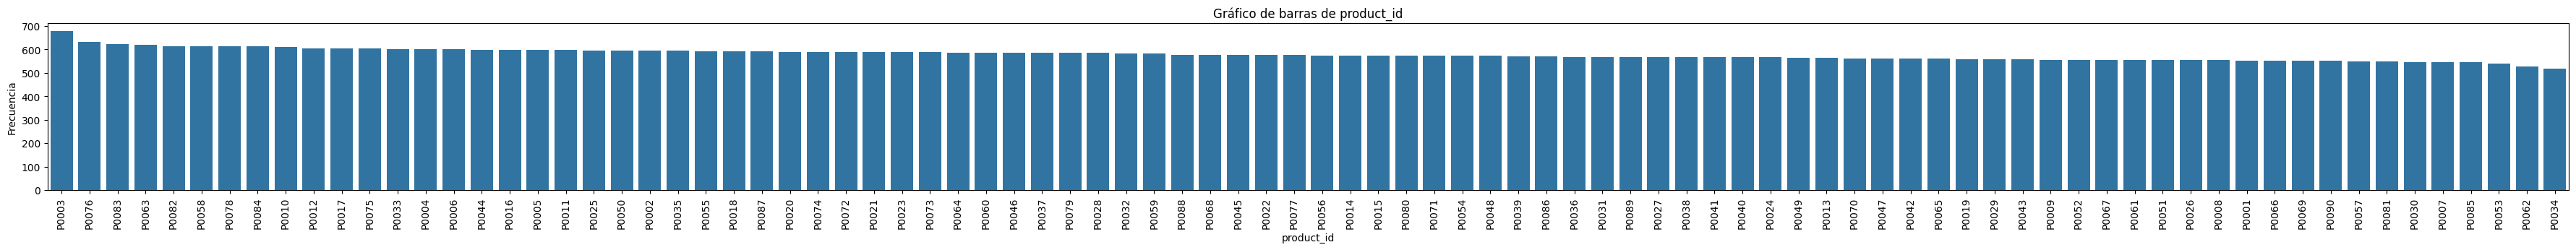

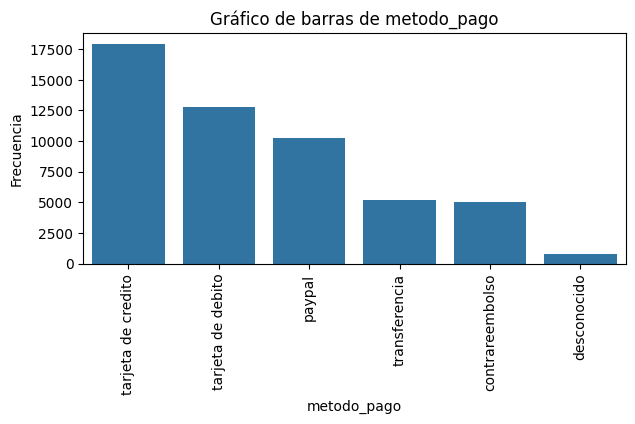

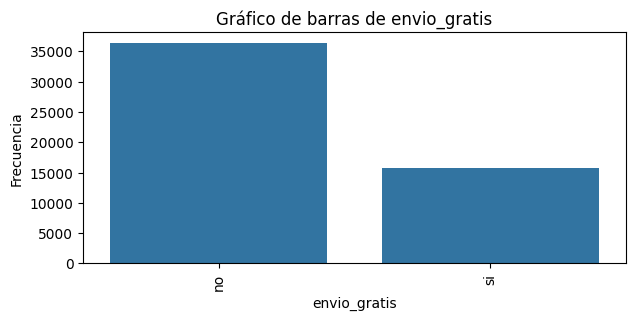

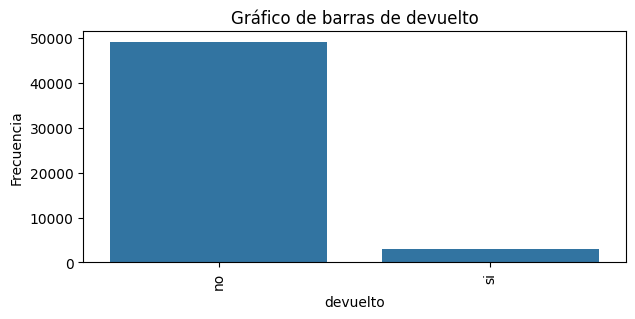

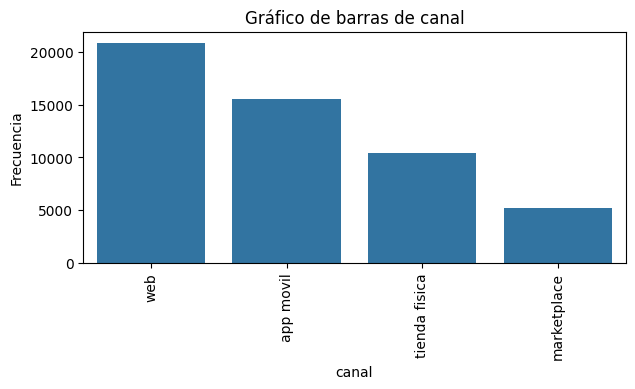

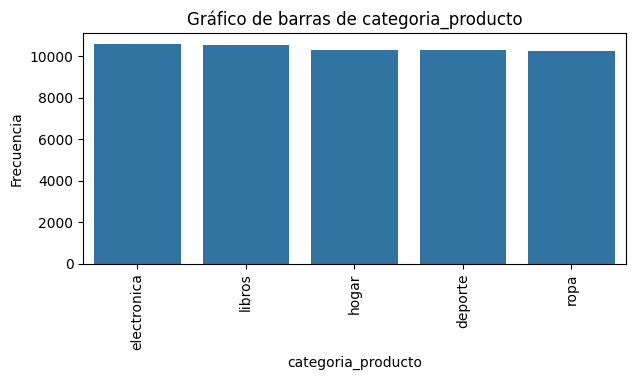

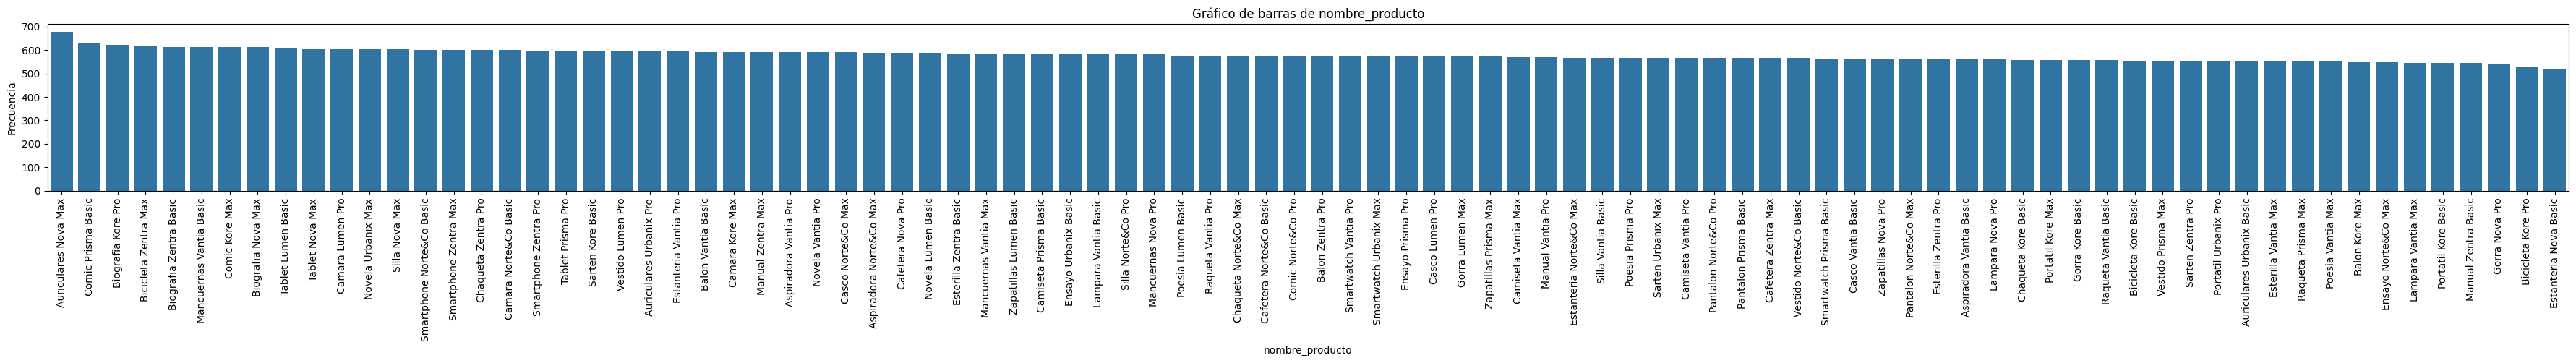

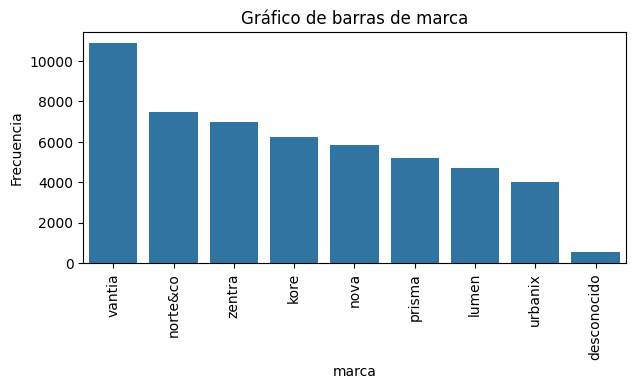

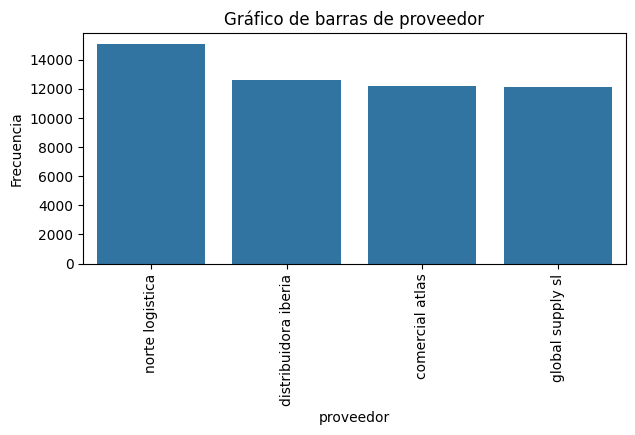

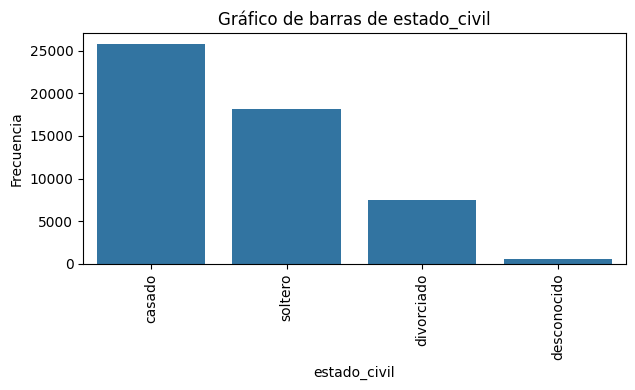

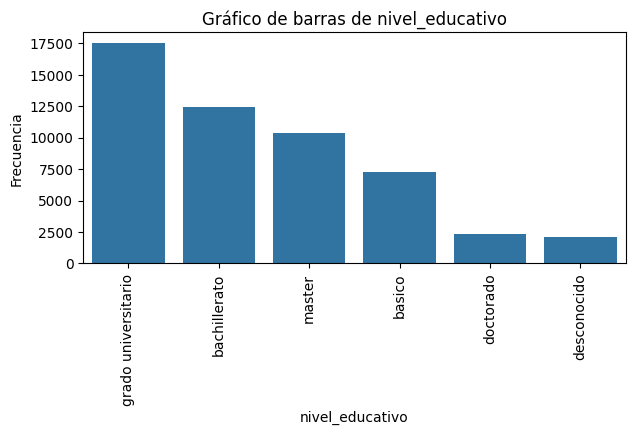

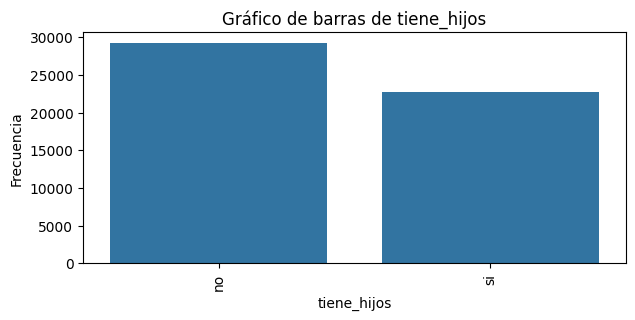

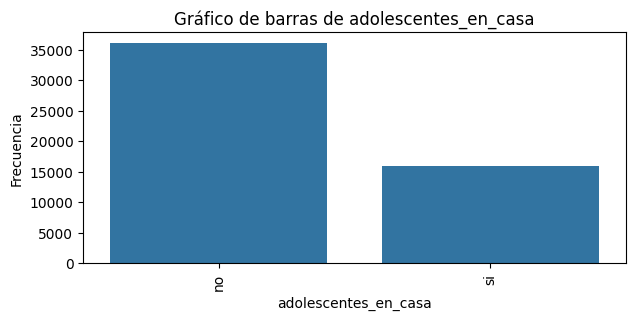

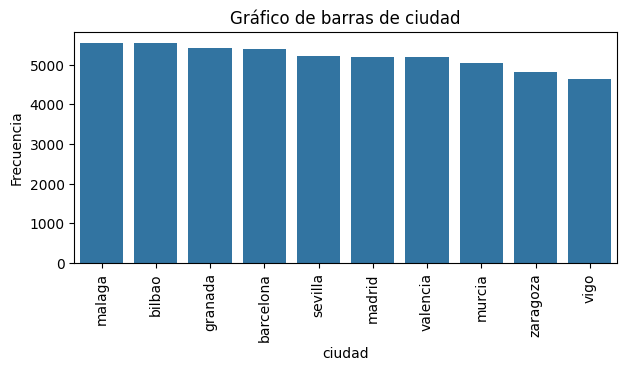

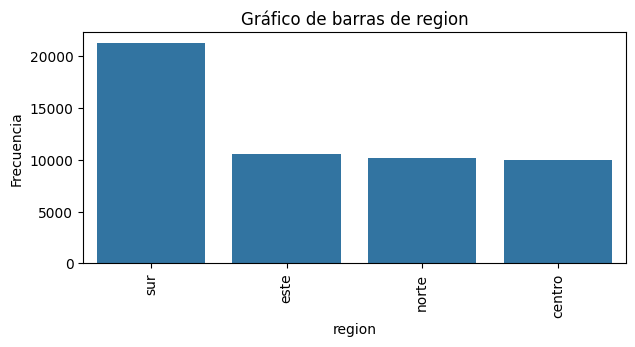

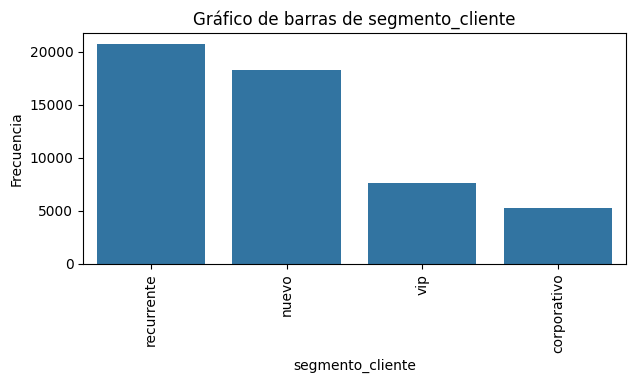


Representación de Histplot:



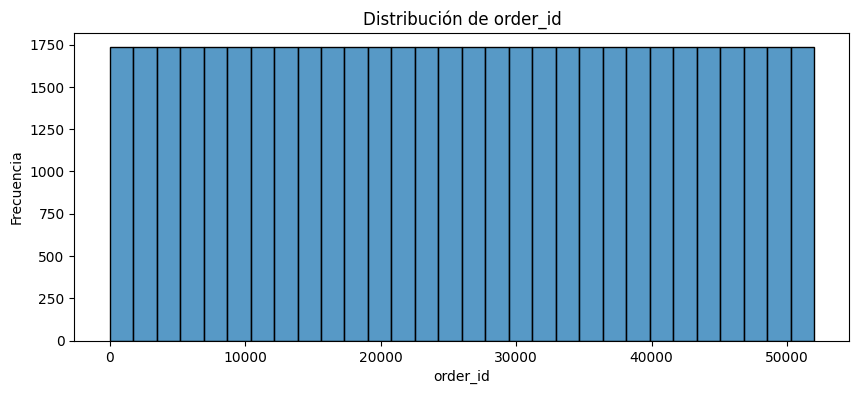

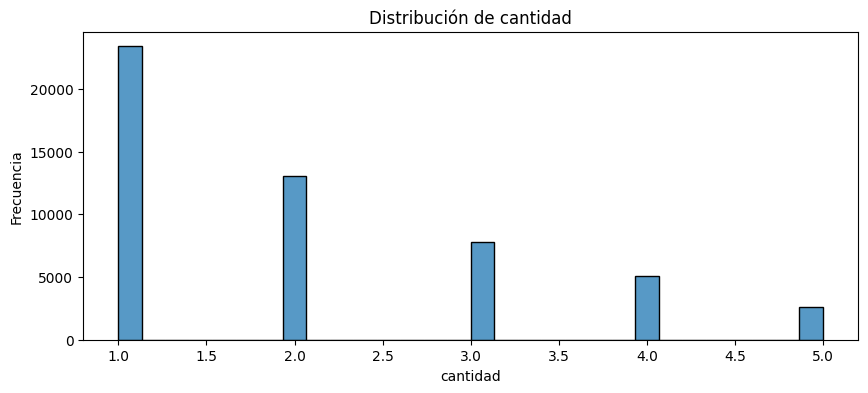

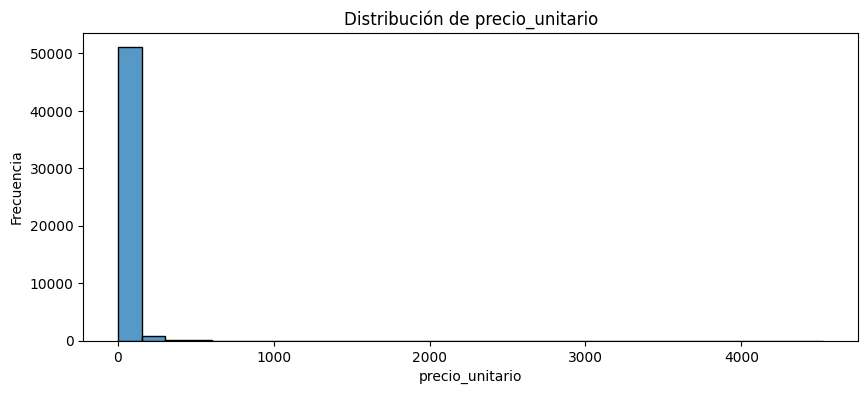

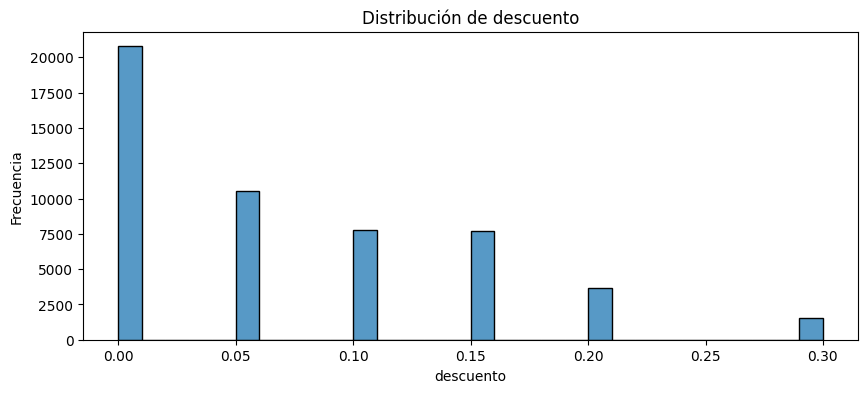

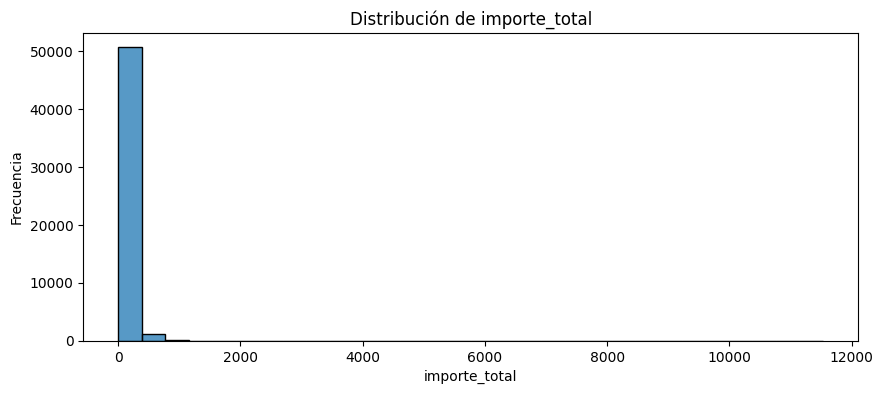

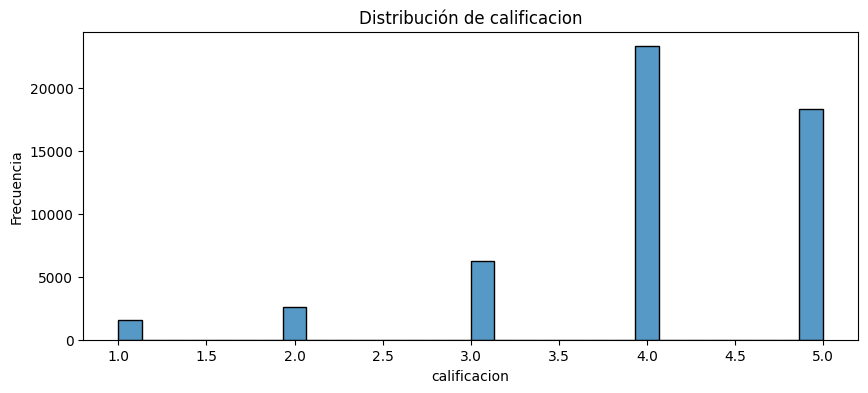

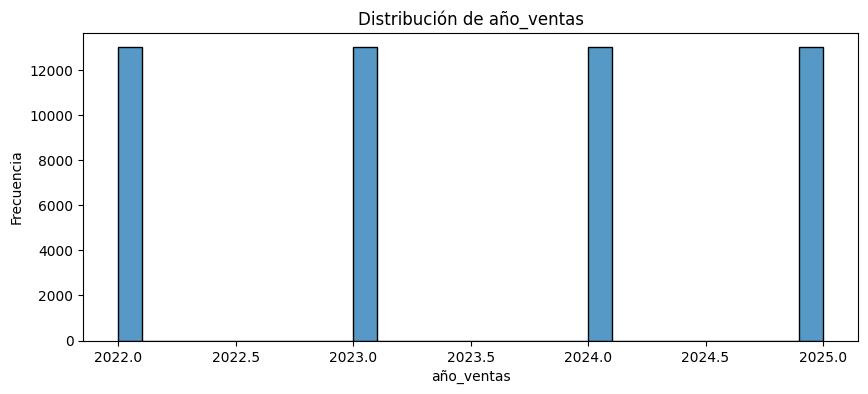

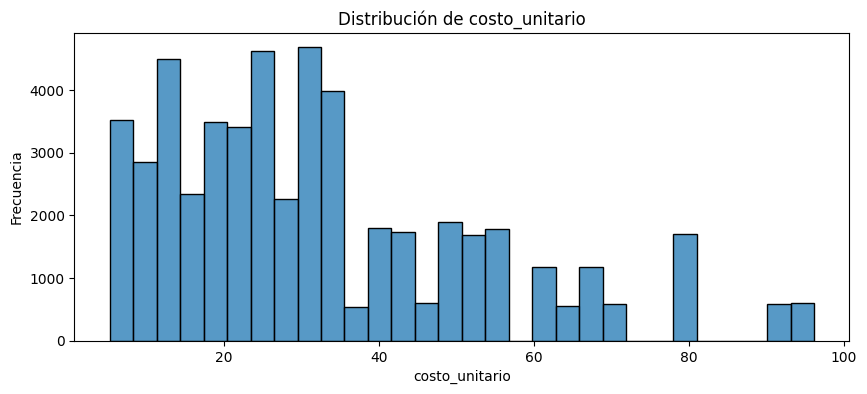

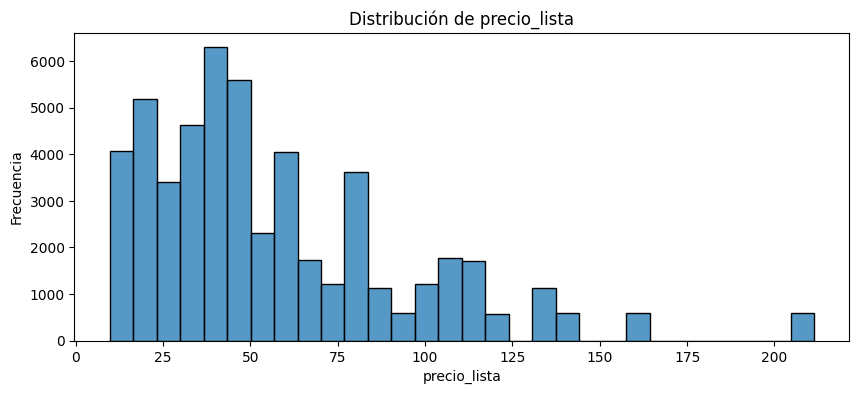

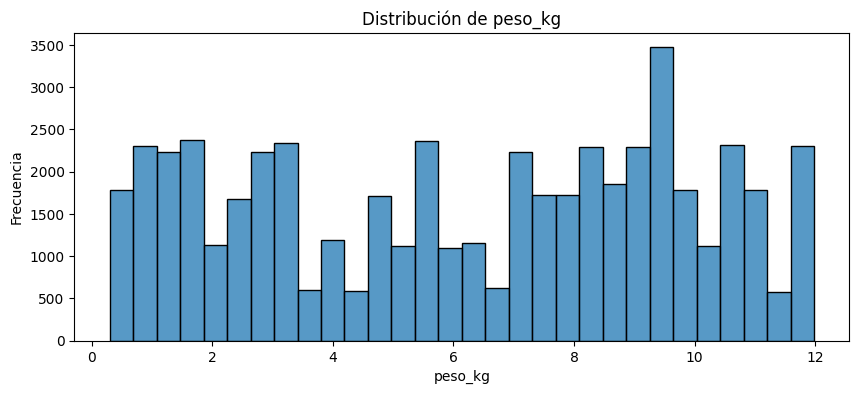

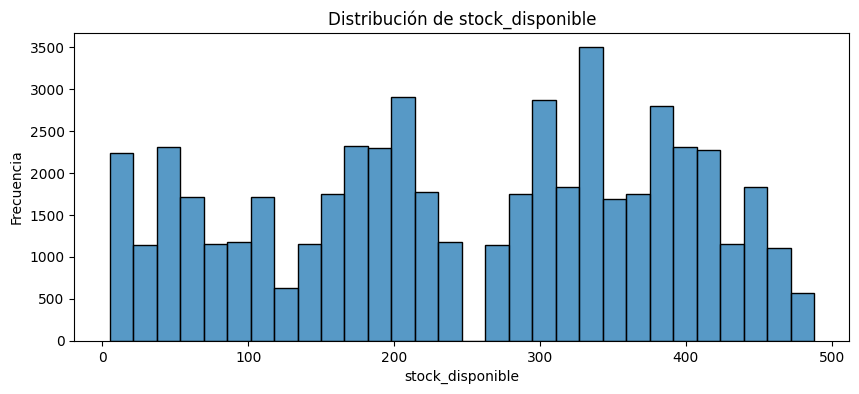

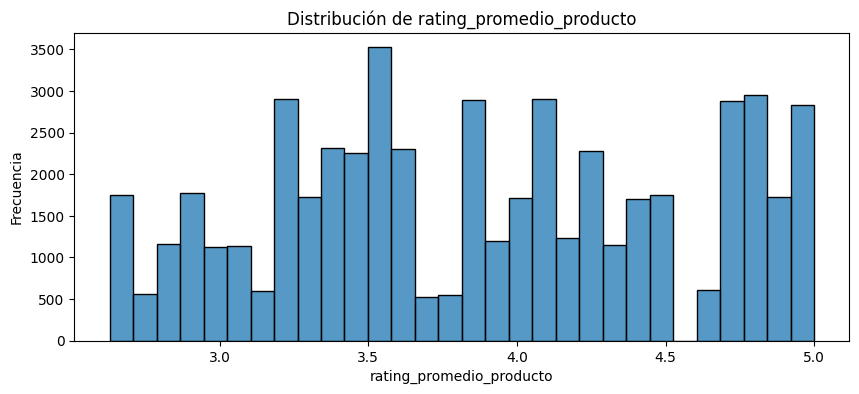

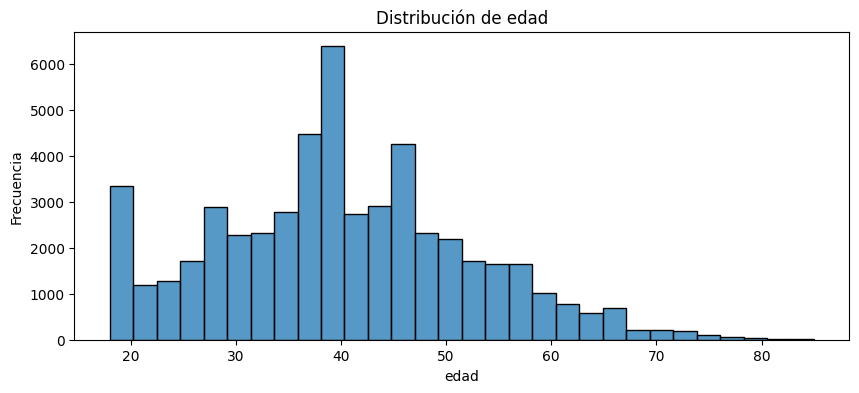

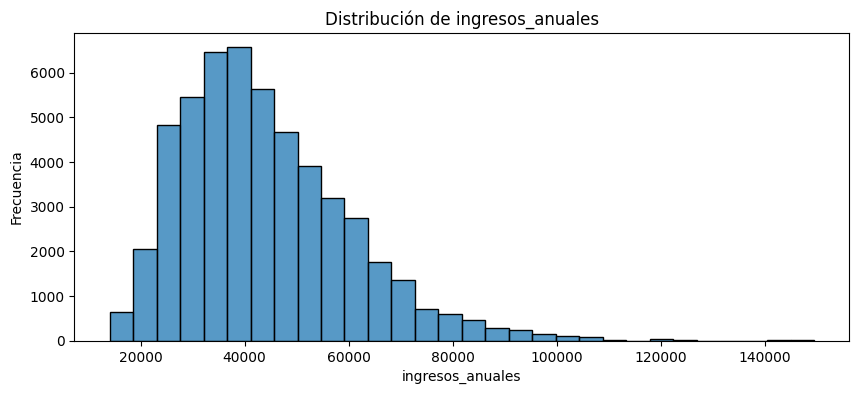

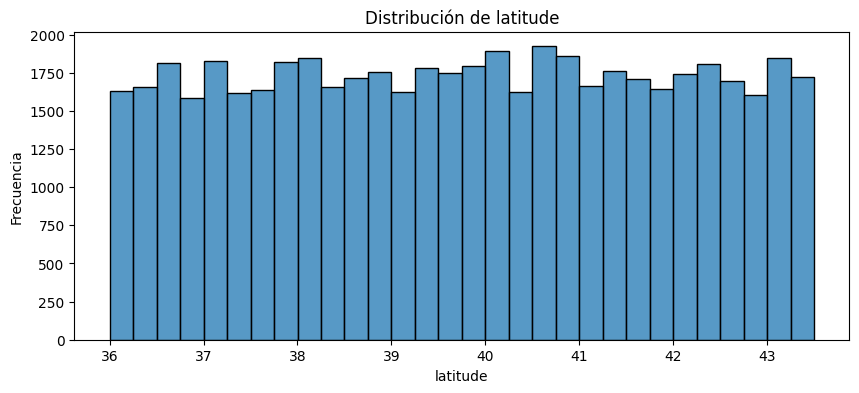

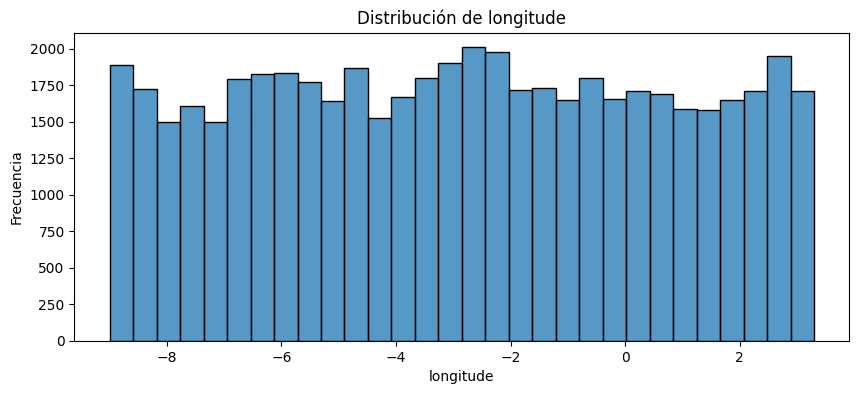

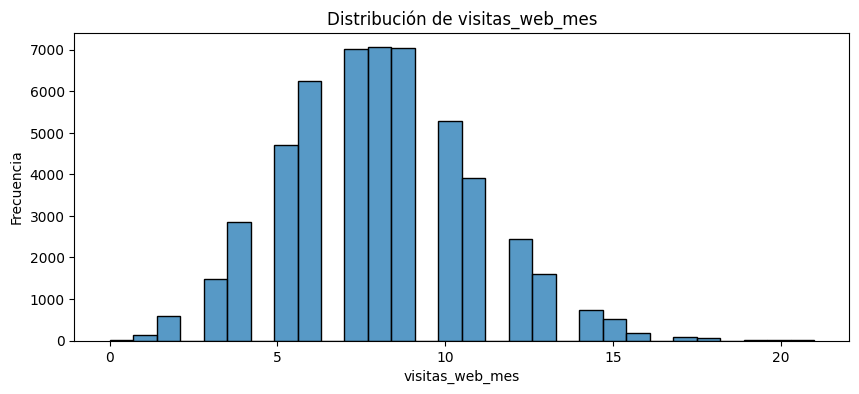

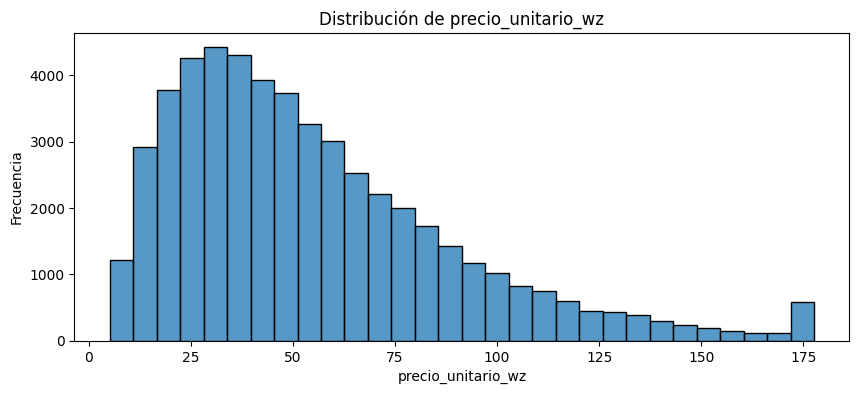

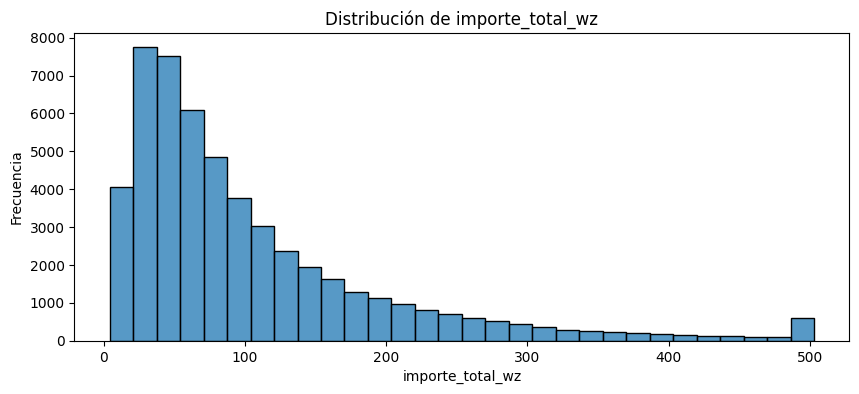


Representación de Boxplot:



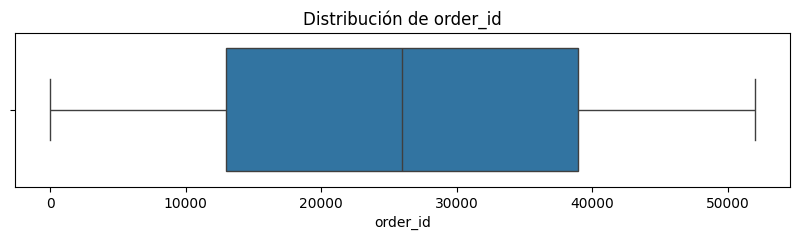

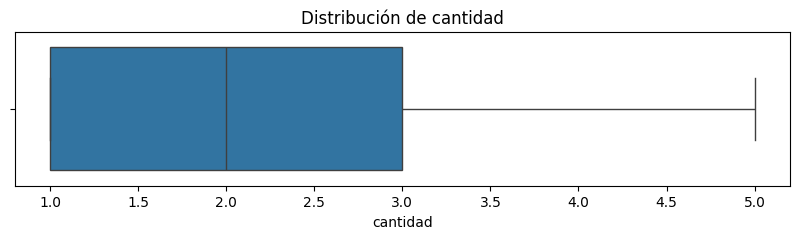

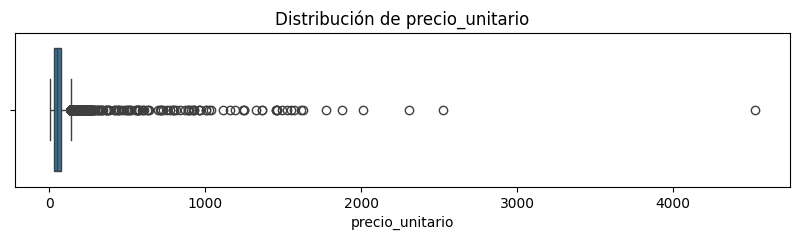

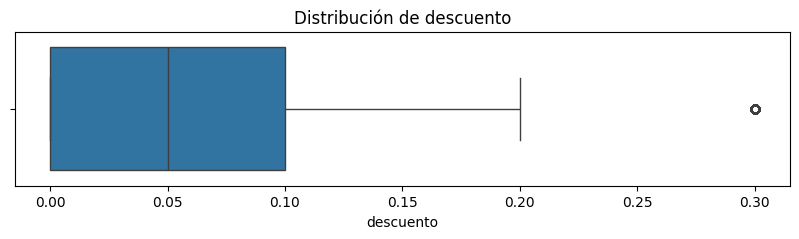

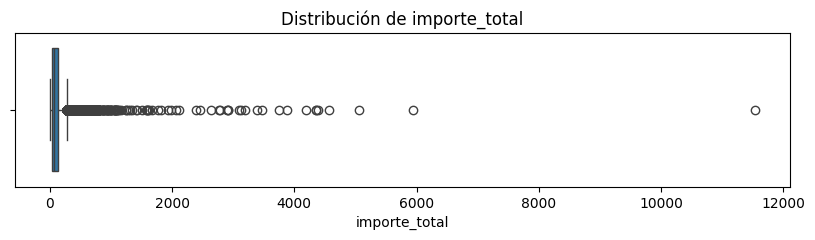

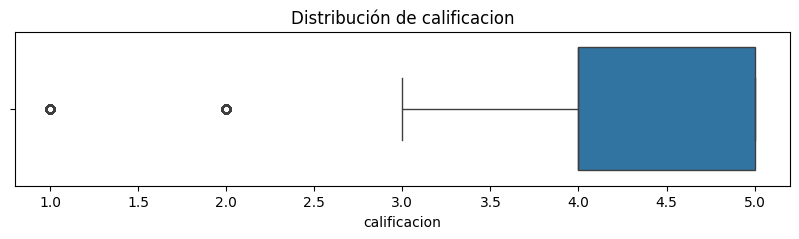

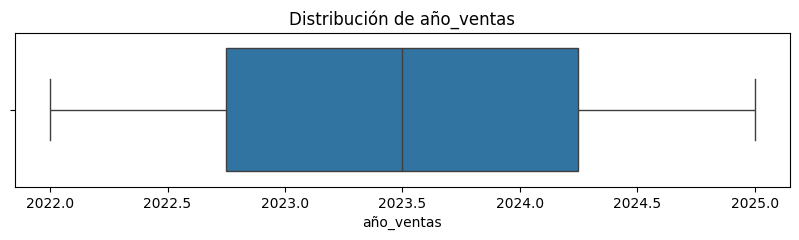

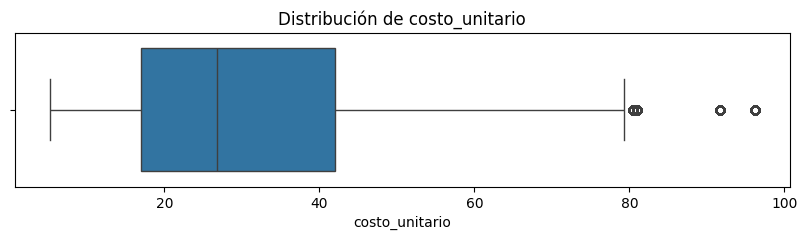

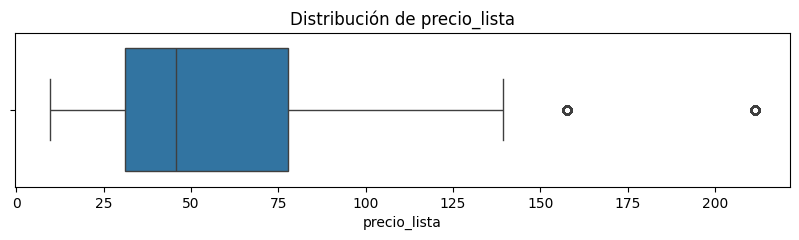

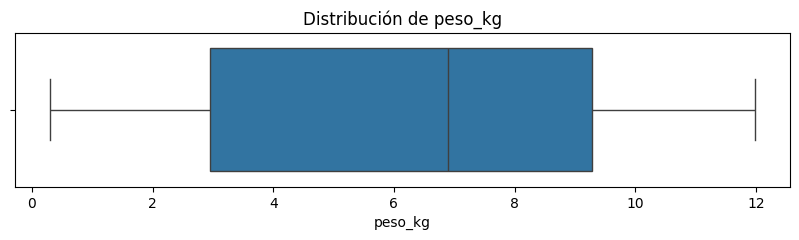

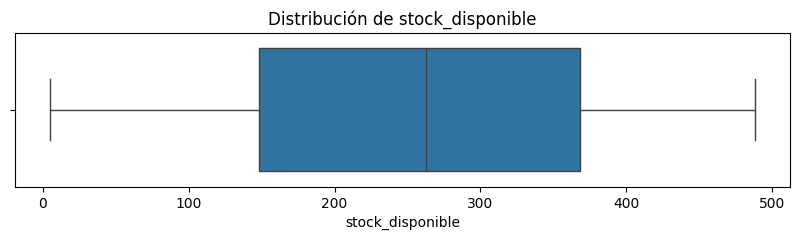

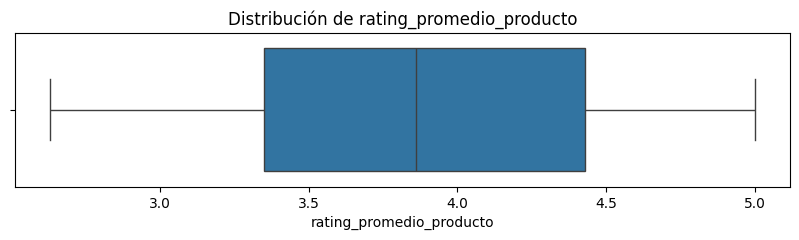

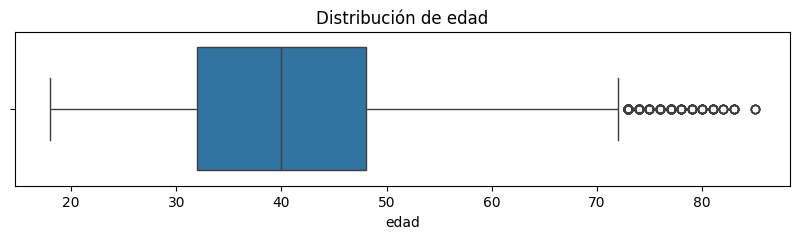

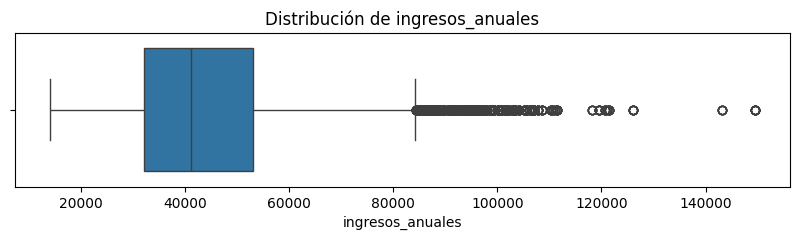

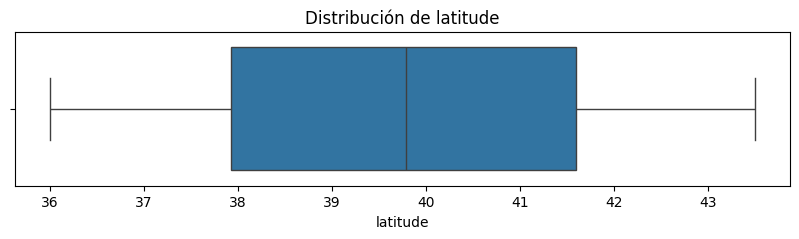

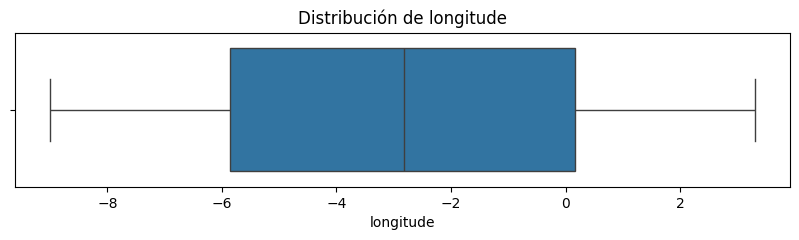

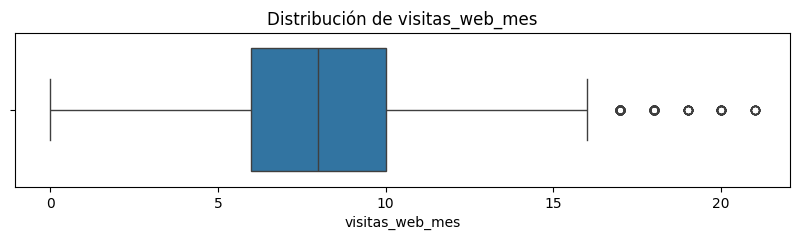

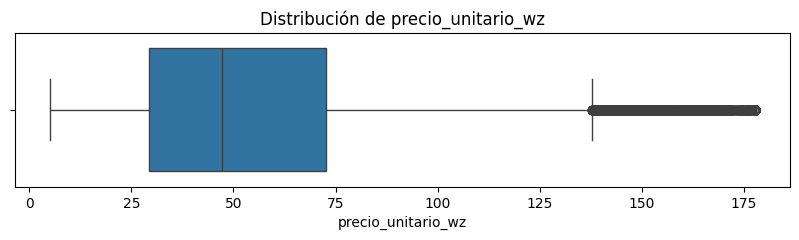

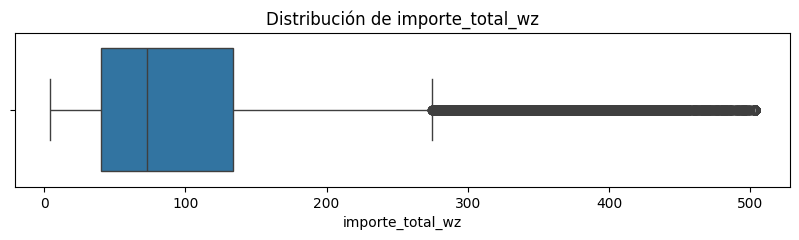

In [8]:
se.eda(df)

In [10]:
cols_excluir = ['order_id', 'id_cliente', 'product_id', 'nombre_producto',
                 'latitude', 'longitude']

Variables numéricas:

 Index(['cantidad', 'precio_unitario', 'descuento', 'importe_total', 'calificacion', 'año_ventas', 'costo_unitario', 'precio_lista', 'peso_kg', 'stock_disponible', 'rating_promedio_producto', 'edad', 'ingresos_anuales', 'visitas_web_mes', 'precio_unitario_wz', 'importe_total_wz'], dtype='str')

Variables categóricas:

 Index(['metodo_pago', 'envio_gratis', 'devuelto', 'canal', 'categoria_producto', 'marca', 'proveedor', 'estado_civil', 'nivel_educativo', 'tiene_hijos', 'adolescentes_en_casa', 'ciudad', 'region', 'segmento_cliente'], dtype='str')

Variables datetime:

 Index(['fecha_pedido', 'fecha_lanzamiento', 'fecha_registro'], dtype='str')

========== ESTADÍSTICAS BÁSICAS ==========

Variables numéricas:
                            count      mean       std       min       25%       50%       75%        max
cantidad                  52000.0      2.05      1.20      1.00      1.00      2.00      3.00       5.00
precio_unitario           52000.0     56.44     56.

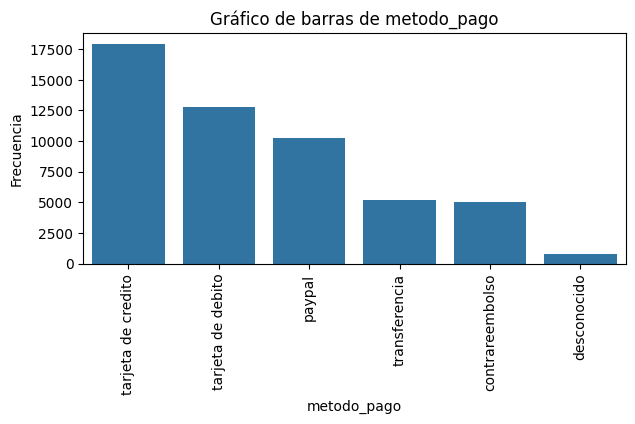

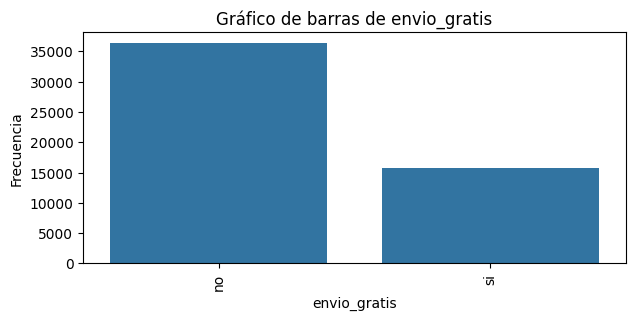

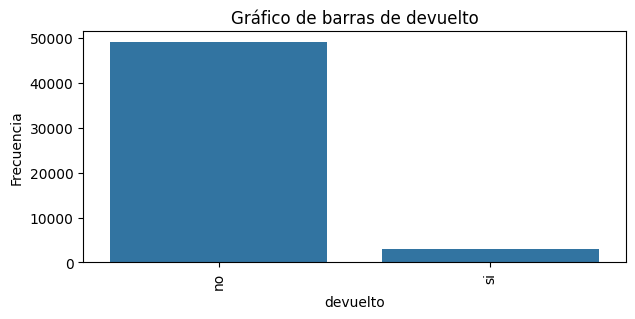

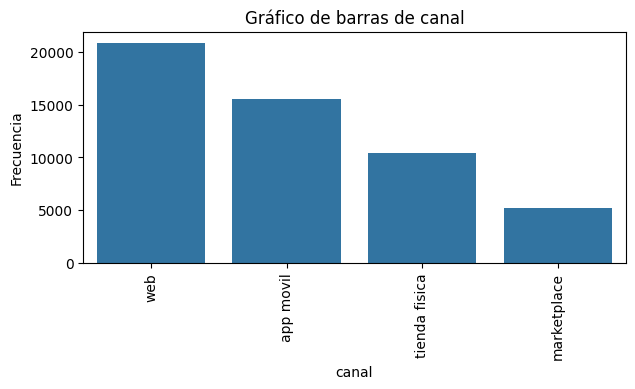

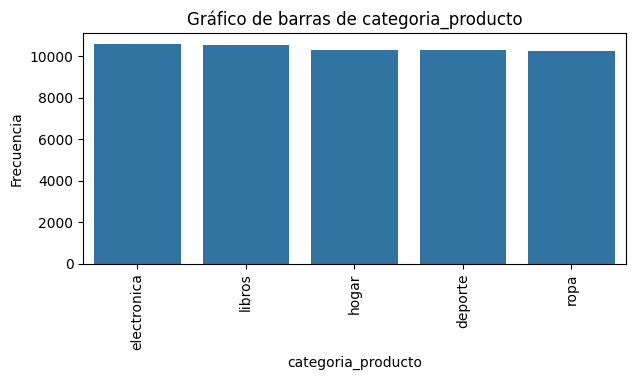

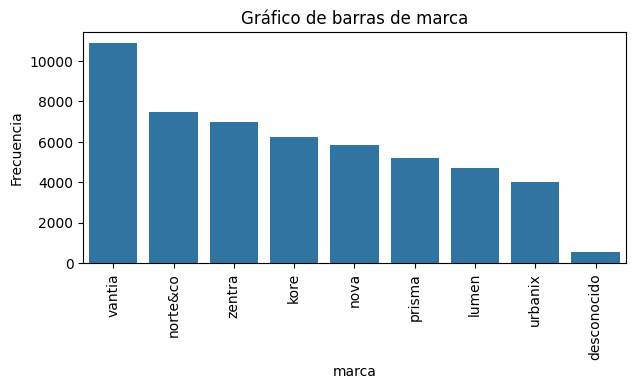

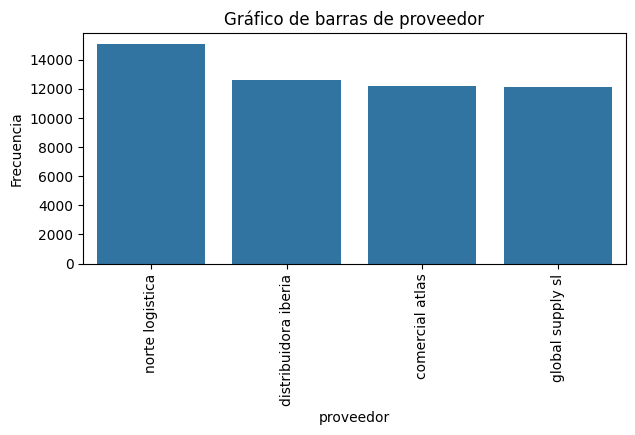

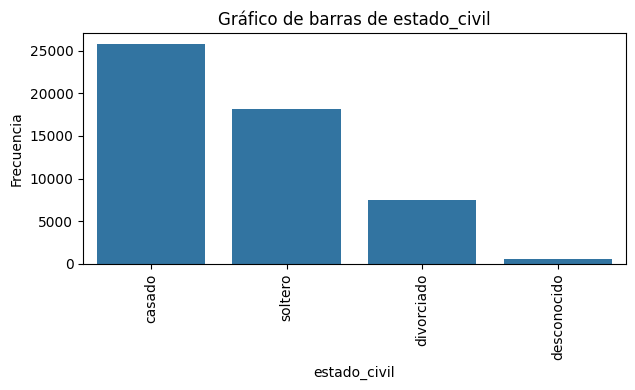

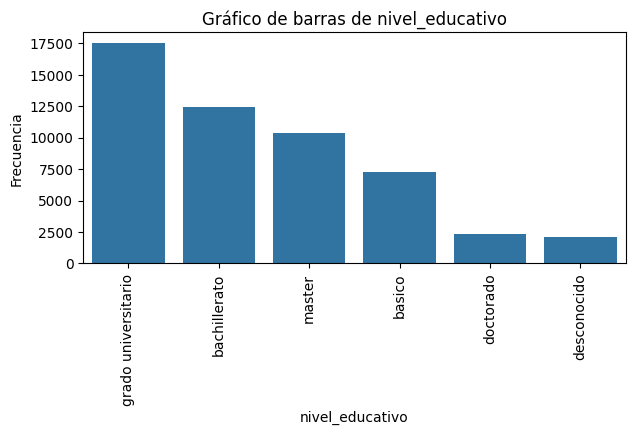

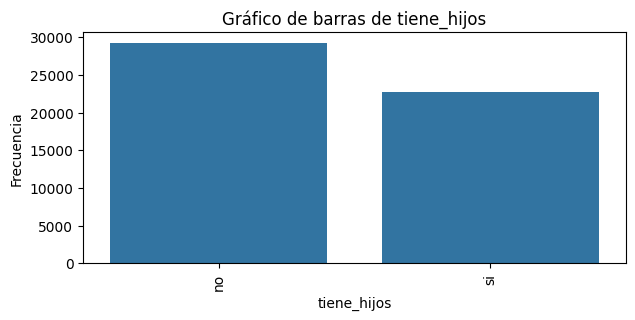

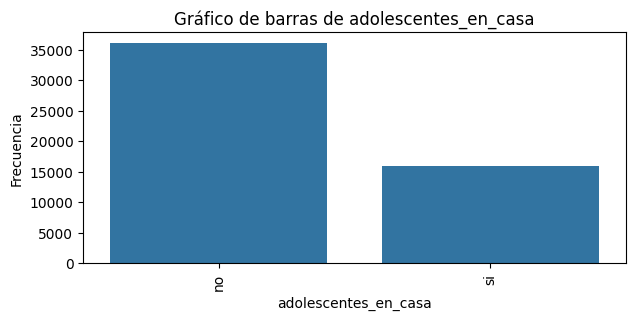

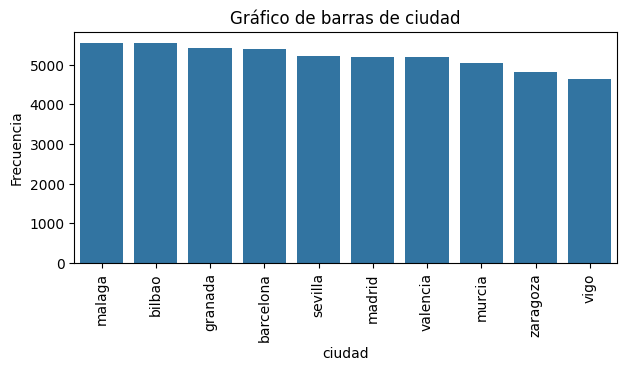

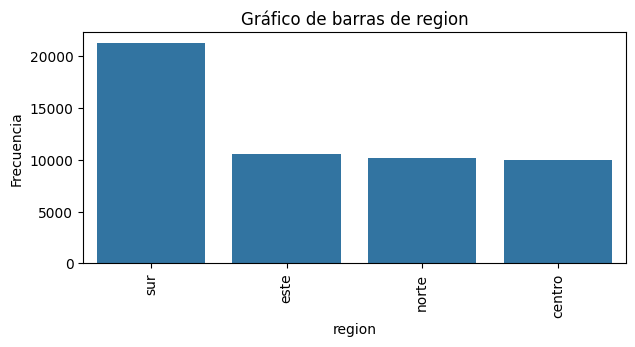

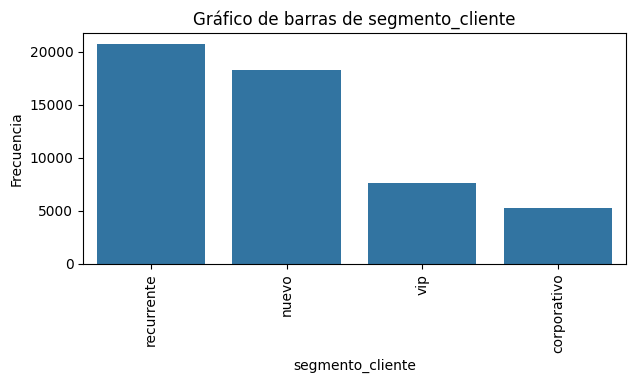


Representación de Histplot:



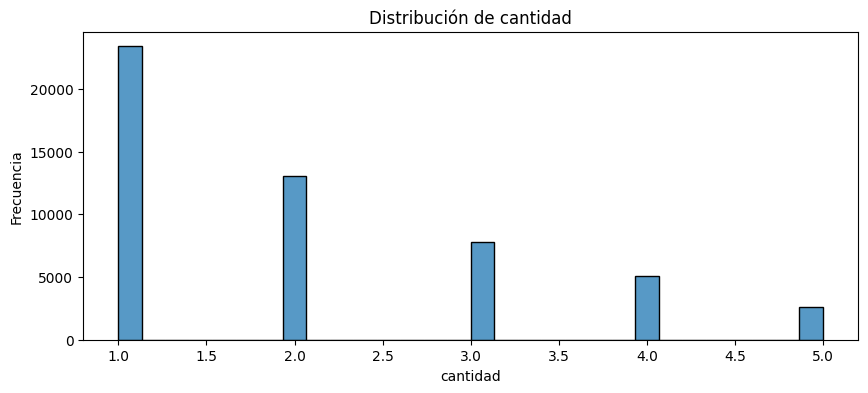

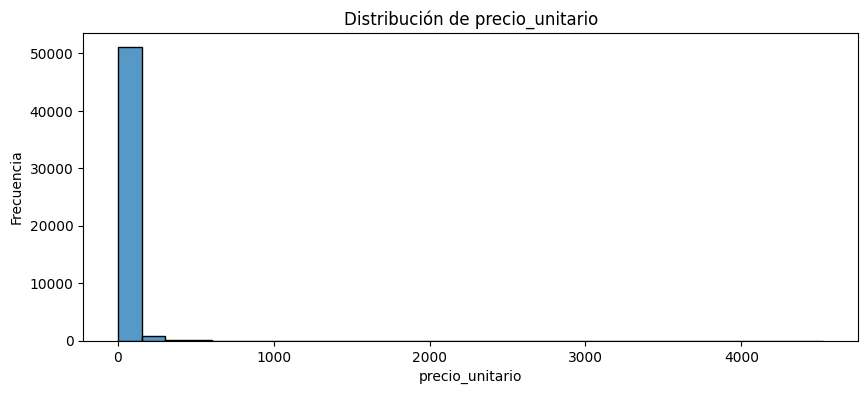

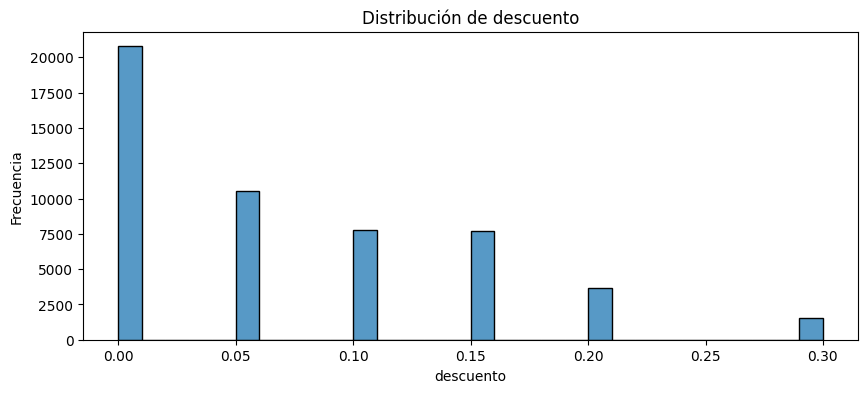

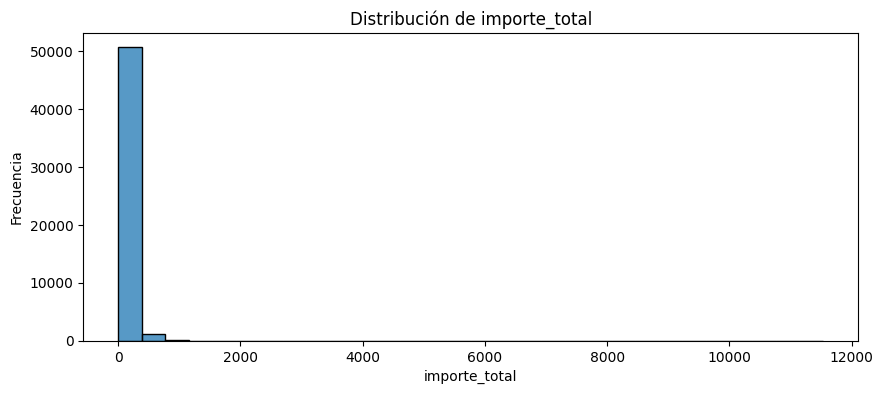

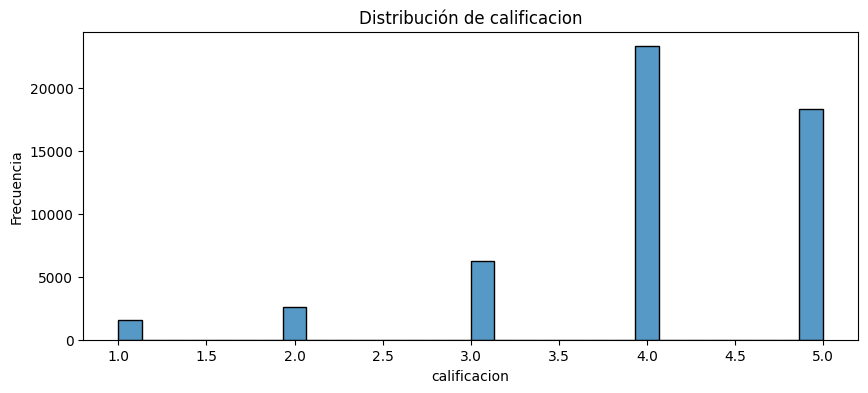

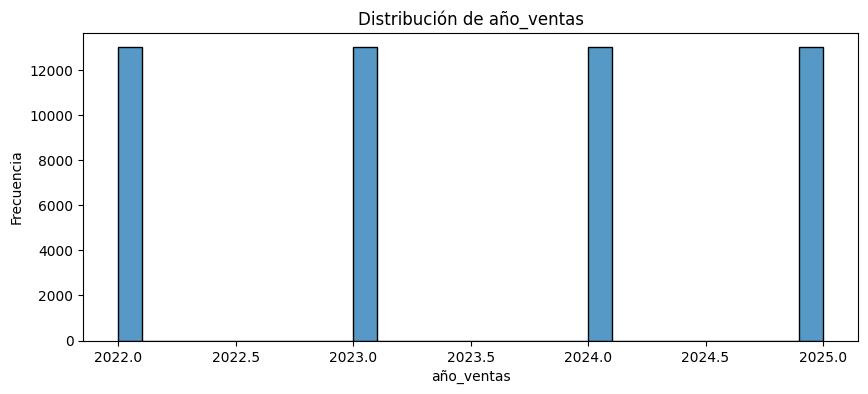

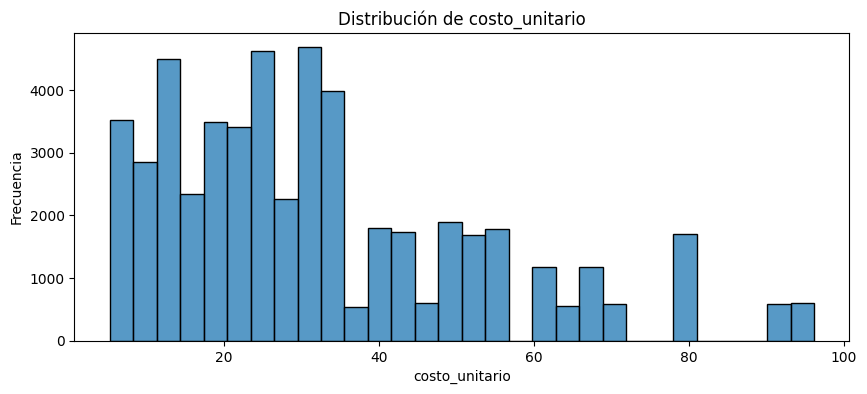

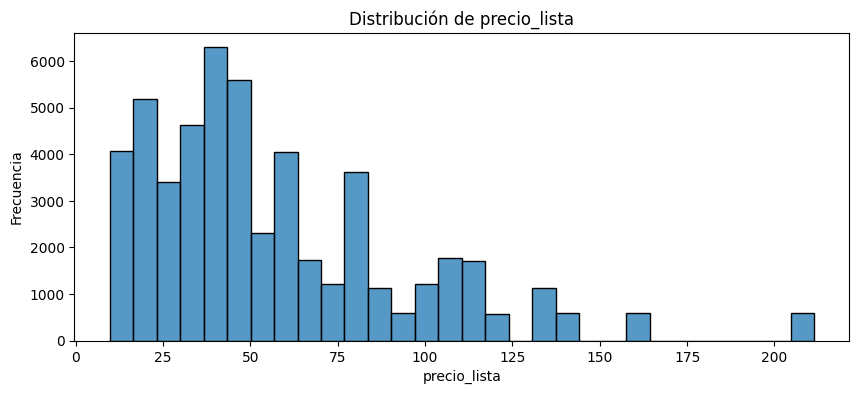

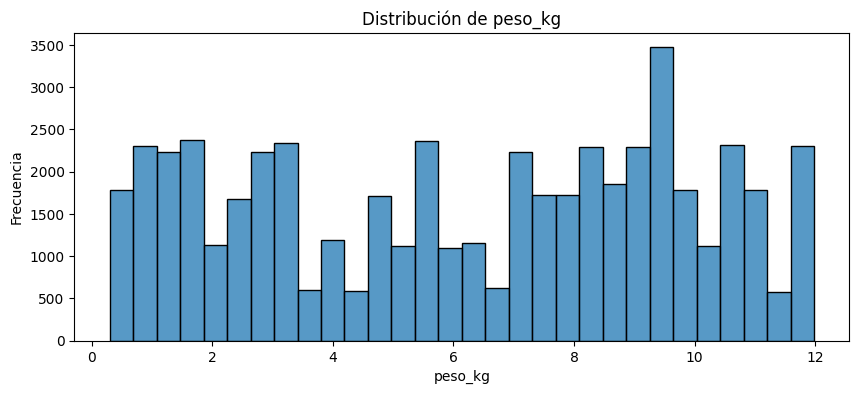

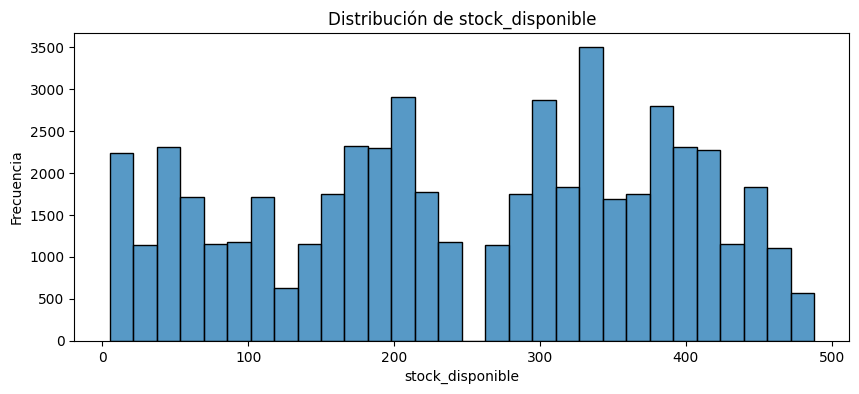

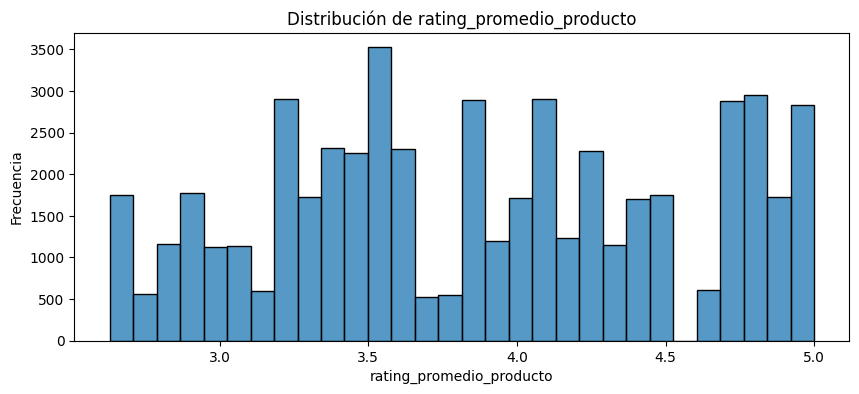

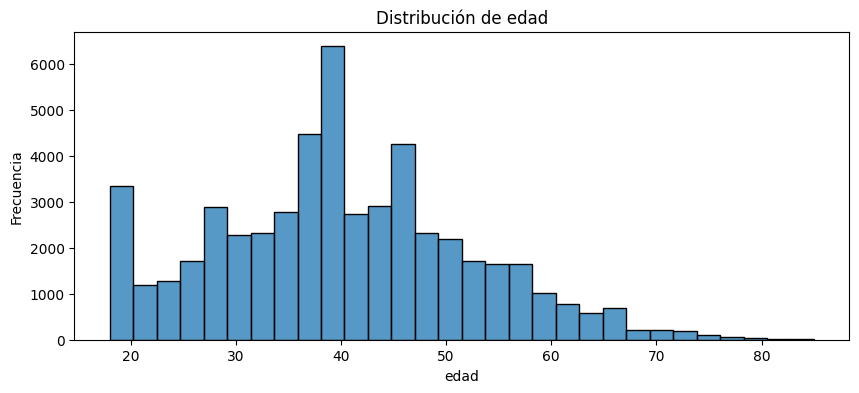

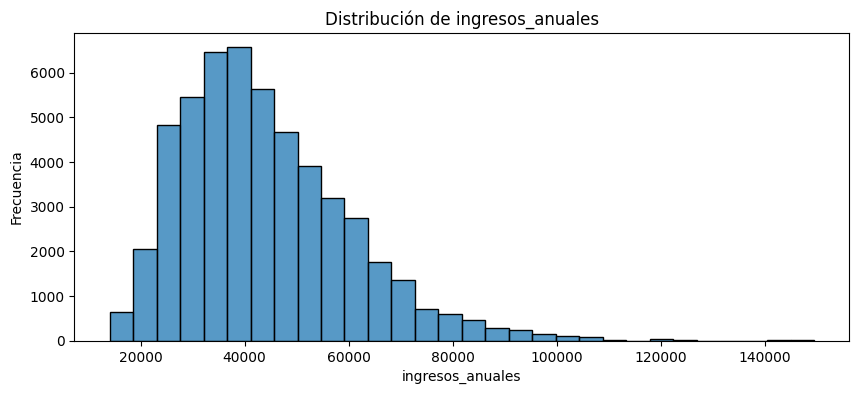

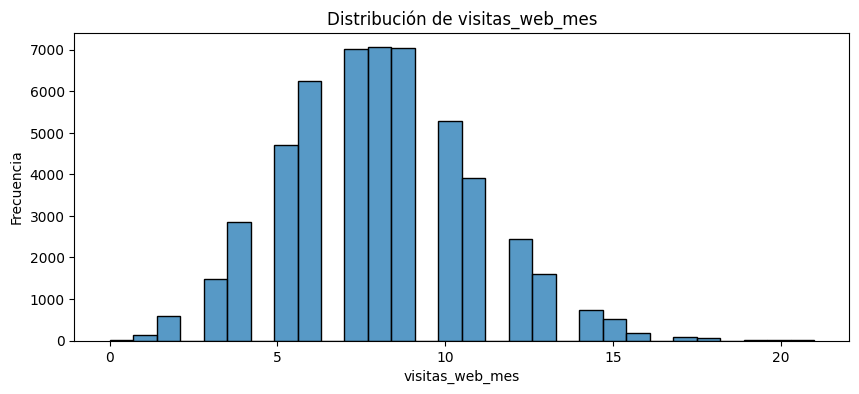

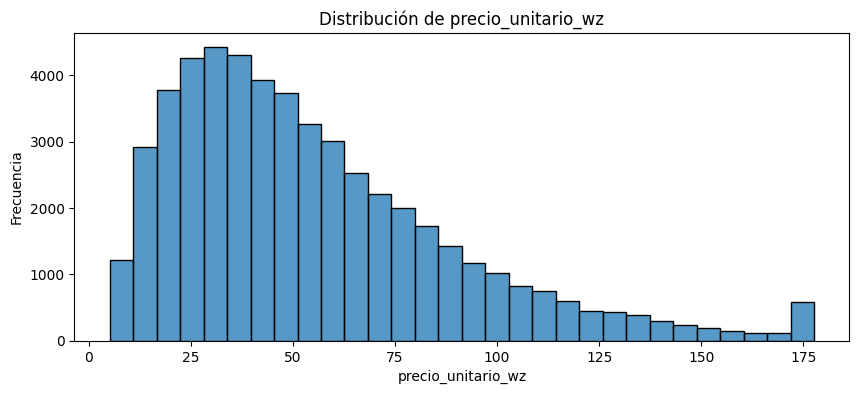

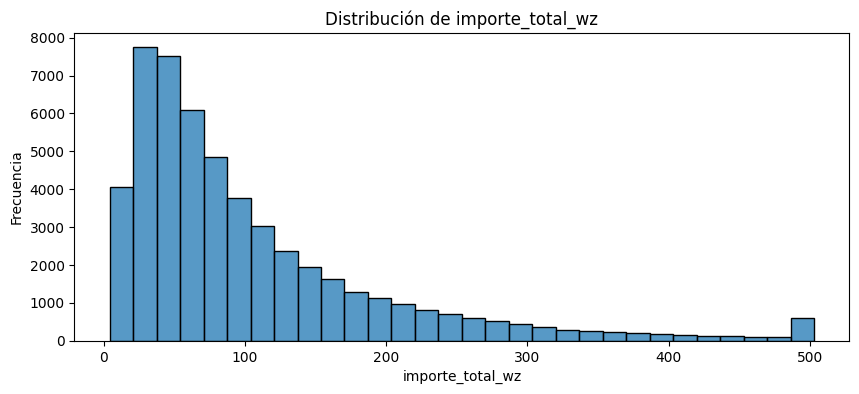


Representación de Boxplot:



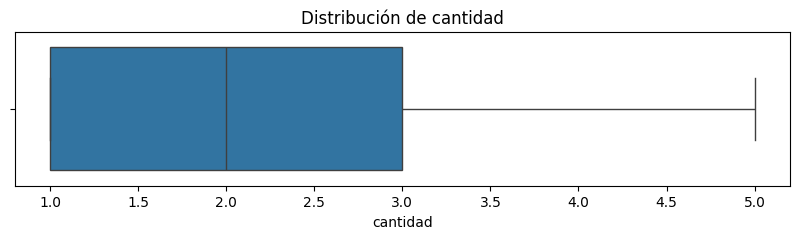

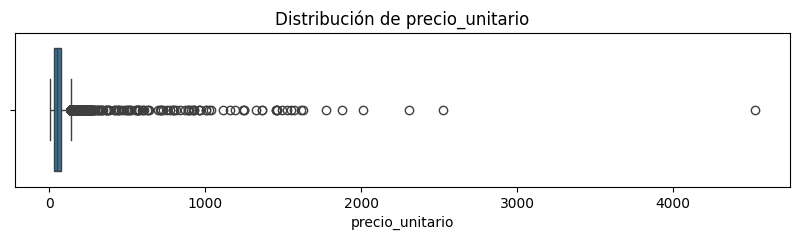

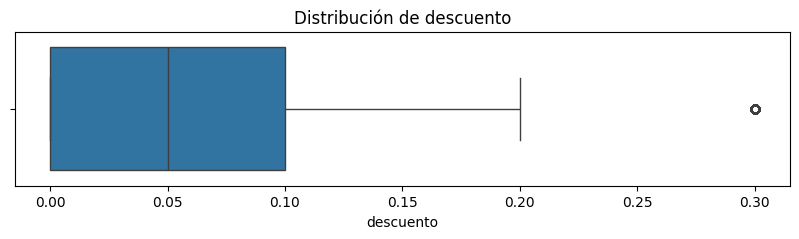

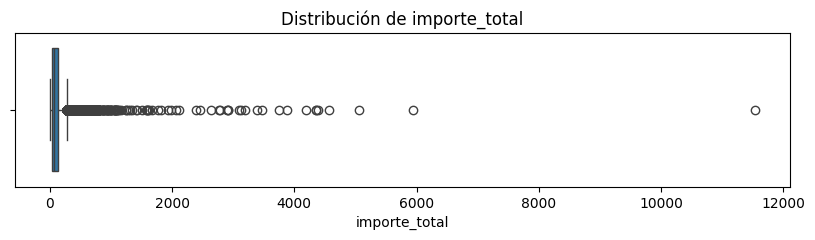

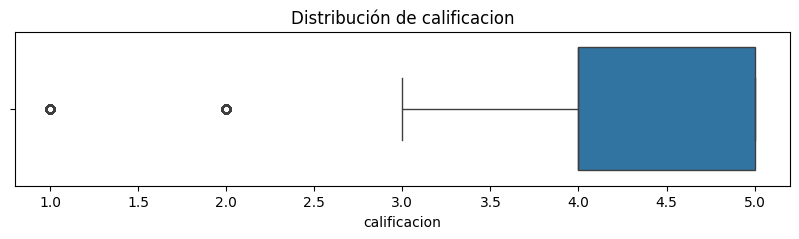

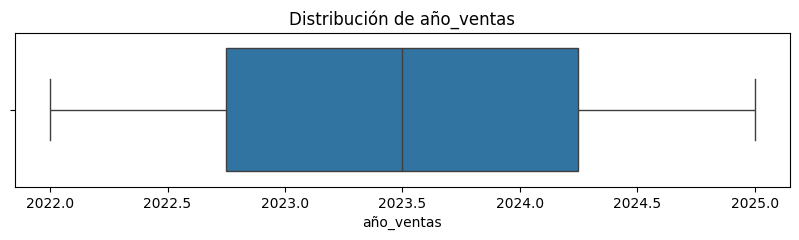

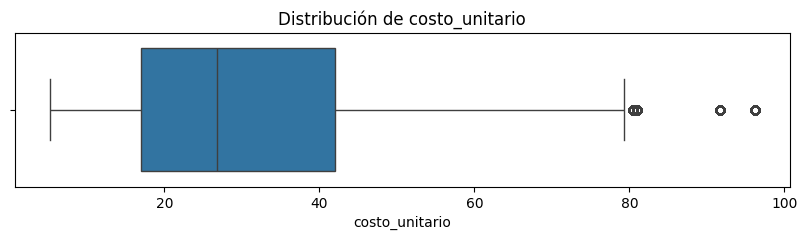

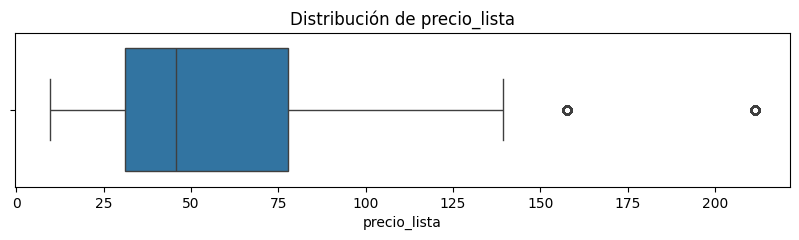

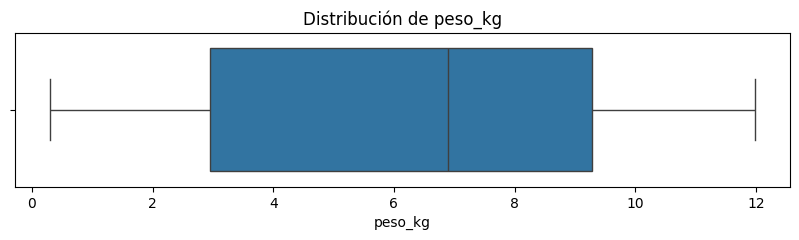

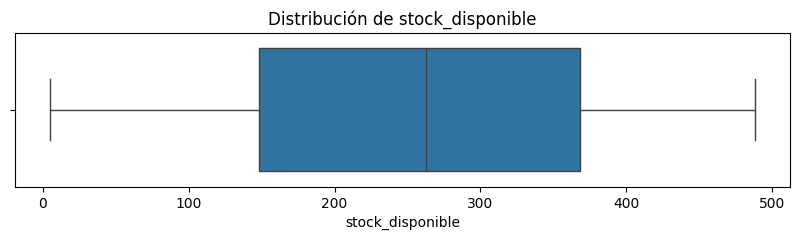

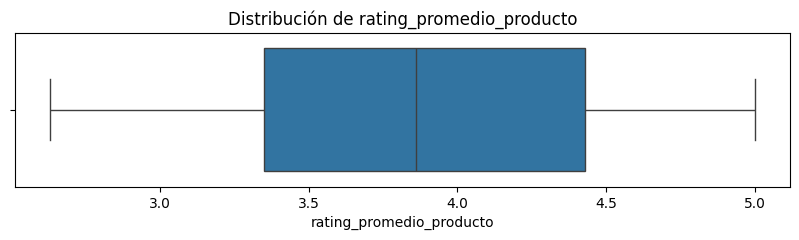

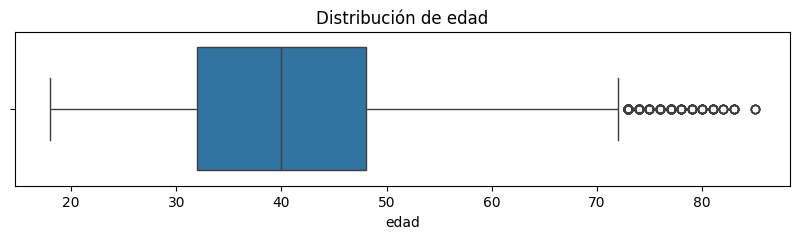

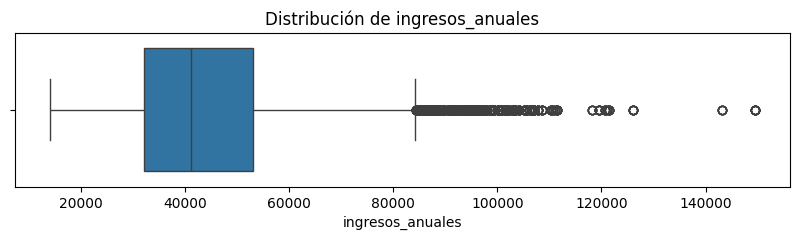

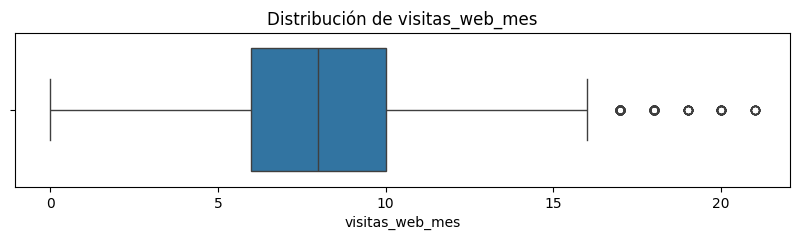

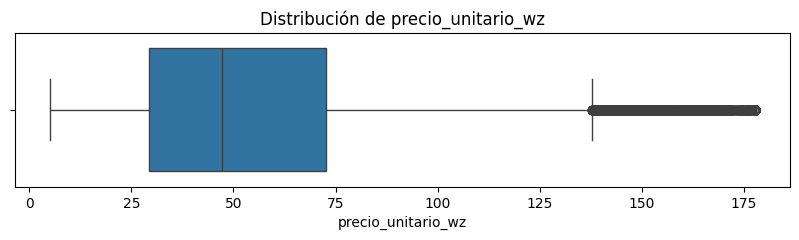

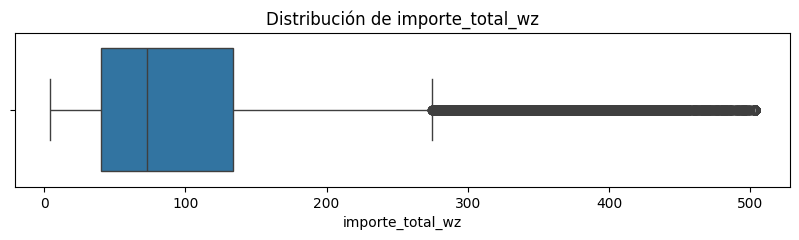

In [11]:
se.eda(df, cols_excluir=cols_excluir)